# Train Main Controller

In [1]:
from wm.controller import Controller
from wm.utils import load_vae, load_rnn
import gymnasium as gym
from flax import nnx
from jaxtyping import Shaped, Array
from wm.agent import Agent

In [2]:
ENV_ID = "CarRacing-v3"
num_envs = 16

In [3]:
vae_name = "beta1.0"
rnn_path = f"../experiments/rnn/{vae_name}"
vae_path = f"../experiments/vae/{vae_name}"

vae, _ = load_vae(vae_path)
rnn = load_rnn(rnn_path)

In [4]:
controller = Controller(rngs=nnx.Rngs(0))
graphdef, state = nnx.split(controller)
agent = Agent(controller=controller, rngs=nnx.Rngs(0))

In [5]:
from tqdm import trange

from wm.utils import prep_obs
import numpy as np
import jax.numpy as jnp
from evosax.algorithms import CMA_ES as ES
import jax
from einops import rearrange


def prepare_obs(obs: Shaped[np.ndarray, "..."], num_envs: int) -> Shaped[Array, "..."]:
    # TODO: faster to concat and then do a strided read?
    obs = np.array([prep_obs(obs[i]) for i in range(num_envs)])
    return jnp.array(np.float32(obs) / 255.0)

In [6]:
# is there a way to do this without reinstantiating the Agent at each timestep?
# the agent would have to accept a controller in __call__ maybe? and do an nnx merge in __call__
# Or the function itself could just use one agent to do the VAE+RNN step and output the input to the agent

# TODO: don't vmap across the whole thing. Rnn and VAE do batched inference - then the agents are
# vmapped by themselves. Fuck the agent
@nnx.jit
@nnx.vmap(in_axes=(0, None, None, 0, 0, 0))  # vmap across the population
def call_agents(individual, carry, env_states, key):
    model = nnx.merge(graphdef, individual)
    agent = Agent(rngs=nnx.Rngs(key), vae=vae, rnn=rnn, controller=model)
    actions, carry = agent(env_states, carry)  # type: ignore
    return (actions, carry)

In [7]:
from wm.vae import VAE
from wm.rnn import MDNRNN

encode = nnx.jit(VAE.encode)
step_rnn = nnx.jit(MDNRNN.step)


@nnx.jit
@nnx.vmap
def call_controllers(individual, x):
    model: Controller = nnx.merge(graphdef, individual)

    actions = model(x)
    return actions


def compute_fitness(population, population_size, envs, num_trials: int = 1):
    cum_reward = np.zeros(population_size)
    for trial in trange(num_trials, leave=False):
        carries = rnn.initialize_carry(population_size)
        obs, _ = envs.reset()
        for _ in range(1000):
            obs = prepare_obs(obs, population_size)
            _, h = carries
            latents = encode(vae, obs).z
            x = jnp.concatenate([latents, h], axis=-1)
            actions = call_controllers(population, x)  # vmap over the controllers.

            rnn_in = jnp.concatenate([latents, actions], axis=-1)
            carries = step_rnn(rnn, rnn_in, carries)

            obs, reward, terminated, truncated, _ = envs.step(np.array(actions))
            cum_reward += reward

    # Evosax minimises the fitness. We want to maximise the reward,
    # so return the negative cumulative reward
    return -cum_reward / num_trials

In [ ]:
num_generations = 50
population_size = 64
num_trials = 16

# Init env
envs = gym.make_vec(ENV_ID, num_envs=population_size, vectorization_mode="async")

# Init evolutionary strategy
key, init_key = jax.random.split(jax.random.key(0), 2)
es = ES(population_size, solution=state)

es_params = es.default_params
es_state = es.init(init_key, state, es_params)


for i in range(num_generations):
    key, key_ask, key_tell = jax.random.split(key, 3)
    population, es_state = es.ask(key_ask, es_state, es_params)
    fitness = compute_fitness(population, population_size, envs, num_trials)
    es_state, info = es.tell(key_tell, population, fitness, es_state, es_params)

    print(f"Step {i + 1:>2}: Best Reward {-info['best_fitness']:.1f}")

Step  1: Best Reward -33.2


Step  2: Best Reward 31.0


Step  3: Best Reward 44.5


Step  4: Best Reward 66.1


Step  5: Best Reward 121.5


...

Step 36: Best Reward 868.5


Step 37: Best Reward 868.5


Step 38: Best Reward 868.5


Step 39: Best Reward 868.5


Step 40: Best Reward 868.5


In [9]:
_, unravel_agent_state = jax.flatten_util.ravel_pytree(state)

best_state = unravel_agent_state(es_state.best_solution)

In [10]:
# observe best agent
model = nnx.merge(graphdef, best_state)
agent = Agent(rngs=nnx.Rngs(key), vae=vae, rnn=rnn, controller=model)

carry = agent.initialize_carry(num_envs=population_size)

obs, _ = envs.reset()


cum_reward = np.zeros(population_size)
observations = []
for i in trange(1000, leave=False):
    obs = prepare_obs(obs, population_size)

    actions, carry = agent(obs, carry)  # type: ignore
    obs, reward, terminated, truncated, _ = envs.step(np.array(actions))
    cum_reward += reward
    observations.append(obs)

In [11]:
import mediapy as media

observations = np.array(observations)
media.show_video(
    observations[:, 1], height=obs.shape[1] * 4, width=obs.shape[2] * 4, fps=90
)

This browser does not support the video tag.


In [22]:
print(f"  Mean: {cum_reward.mean():.0f}")
print(f"Median: {np.median(cum_reward):.0f}")
print(f"   Max: {cum_reward.max():.0f}")
print(f"   Min: {cum_reward.min():.0f}")

print("\n All rewards:")
all_rewards = cum_reward.round(0).astype(np.int64)
all_rewards.sort()
print(all_rewards)

  Mean: 716
Median: 763
   Max: 1055
   Min: 241

 All rewards:
[ 241  350  368  375  403  433  459  466  482  509  530  577  578  580
  593  596  604  615  644  655  672  673  684  707  708  724  743  745
  746  760  761  761  765  786  789  795  799  803  813  814  815  818
  822  832  834  837  843  847  849  850  852  856  857  858  858  859
  869  873  878  885  885  885  886 1055]


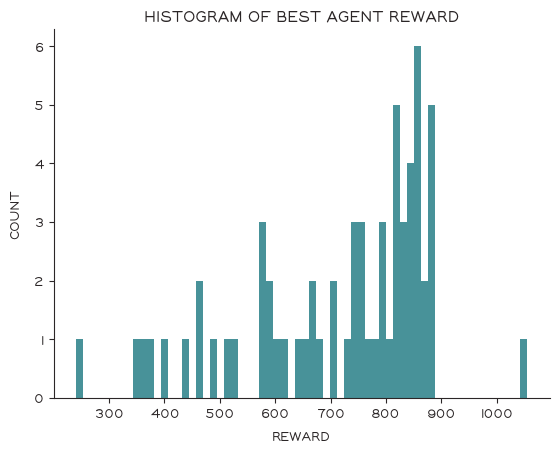

In [16]:
import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")
plt.xlabel("Reward")
plt.ylabel("Count")
plt.title("Histogram of best agent reward")
plt.hist(cum_reward, bins=64);